In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import h5py
import json
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Import the dataset class
import sys
sys.path.append('../src/data')
from dataset_generator import DOADataset
import visualization

%matplotlib widget
print("Imports successful!")


Imports successful!


In [2]:
# Configure dataset path
DATASET_NAME = "ula_dataset_90"  # Change this to your dataset name
DATASET_TYPE = 'linear'
DATASET_PATH = f"../Data/datasets/{DATASET_TYPE}/{DATASET_NAME}/{DATASET_NAME}.h5"

# Load dataset
dataset = DOADataset(DATASET_PATH)
print(f"Loaded dataset with {len(dataset)} samples")

# Display label summary
print("\nLabel Summary:")
for label, summary in dataset.get_label_summary().items():
    print(f"  {label}: {summary}")


Loaded dataset with 36000 samples

Label Summary:
  array_imperfections: True: 18000, False: 18000
  doas: Total DOAs: 72000, Range: [0.0, 180.0]
  num_multipath: Unique values: [0]
  num_snapshots: Unique values: [1024]
  num_sources: Unique values: [[1, 0], [1, 1], [1, 2]]
  sir: Range: [0.0, 0.0] dB, sir exists: 36000
  smr: All invalid values
  snr: Range: [-10.0, 15.0] dB, snr exists: 36000


In [3]:
dataset.has_array_models


True

In [56]:
snr = 0
filtered_dataset = dataset.filter(snr=snr)

In [95]:
one_source_dataset = filtered_dataset.filter(num_sources=[1, 0])
two_source_dataset = filtered_dataset.filter(num_sources=[1, 1])
three_source_dataset = filtered_dataset.filter(num_sources=[1, 2])
ds = three_source_dataset.filter(array_imperfections=False)

In [97]:
idx = 1
sample = ds[idx]
print(sample['labels']['array_imperfections'])
array_model = ds.get_array_model(idx)
angles = np.arange(0, 181, 1)
A_nominal = array_model.steering_matrix(angles, nominal=True)



False


In [98]:
from models.classic import Beamformer, MVDR, MUSIC, RootMUSIC

# Initialize all three estimators
bart = Beamformer(array_model, A_nominal, angles)
mvdr = MVDR(array_model, A_nominal, angles)
music = MUSIC(array_model, A_nominal, angles)
root_music = RootMUSIC(array_model, A_nominal, angles)

In [99]:
alg = music

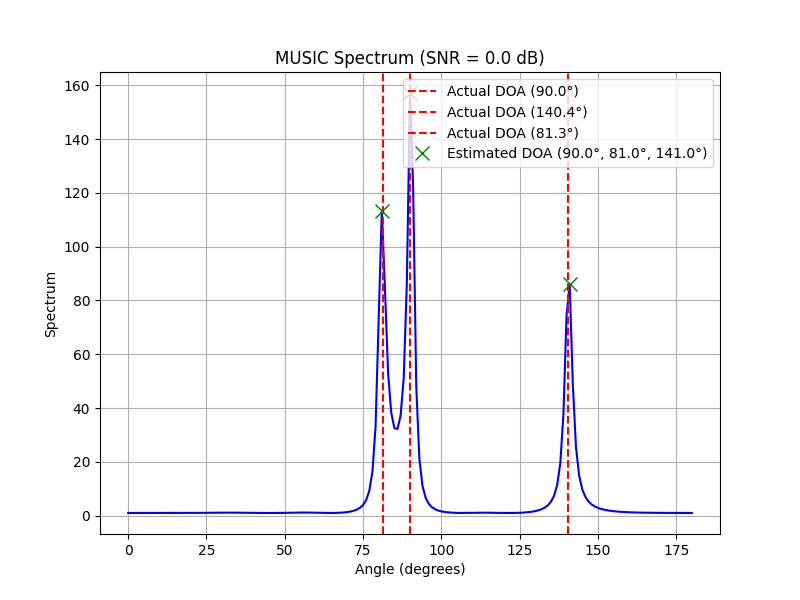

In [100]:
num_sources = sample['labels']['num_sources'].sum()
alg.set_received_data(sample['received_signal'])
alg.num_sources = num_sources
real_angles = sample['labels']['doas']
if alg == root_music:
    estimted_doa, spectrum, _, _, _ = alg.estimate_doa()
else:
    estimated_doa, spectrum = alg.estimate_doa()

# Plot the spectrum with actual and estimated angles
plt.figure(figsize=(8, 6))
plt.plot(angles, spectrum, color='blue')
plt.title(f'MUSIC Spectrum (SNR = {sample["labels"]["snr"]:.1f} dB)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Spectrum')

# Add vertical lines for actual angles
for i, angle in enumerate(real_angles):
    plt.axvline(x=angle, color='r', linestyle='--', label=f'Actual DOA ({angle:.1f}°)')

# Mark estimated angles with x markers
plt.plot(estimated_doa, [spectrum[np.where(angles == angle)[0][0]] for angle in estimated_doa], 
         'x', color='g', markersize=10, 
         label=f'Estimated DOA ({", ".join([f"{angle:.1f}°" for angle in estimated_doa])})')

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.grid(True)
plt.show()
